In [1]:
## Analysis of Mintflow outputs for renal cell carcinoma dataset
## Whole dataset and T cell subclustering, with accuracy metrics compared to scVI clusters
## Dr Daniyal Jafree, Lotfollahi Group, CellGen Programme, Wellcome Sanger Institute
## Final Version - 20th July 2025

In [2]:
## Set up environment

# local settings, change path if needed
rootdir_inflow = "/nfs/users/nfs_d/dj17/inflow_version3/inflow"  # Change this path if needed

import spatialdata as sd
from spatialdata_io import xenium
import squidpy as sq
from pathlib import Path
import os, sys
import numpy as np
from scipy.sparse import issparse
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import numpy as np
import pandas as pd
import torch
import anndata
import glasbey
from tqdm.autonotebook import tqdm
import gc
import time
import scvi
import os

list_pathstoadd = [
    rootdir_inflow,
    os.path.join(rootdir_inflow, "src"),
    os.path.join(rootdir_inflow, "src", "inflow")
]

for path in list_pathstoadd:
    if(path not in sys.path):
        sys.path.append(path)
        
import inflow

from inflow.cli import parse_config_data_train, parse_config_data_test, parse_config_training, parse_config_model

/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata

In [3]:
# Set seed
sc.settings.verbosity = 3
sc.settings.seed = 0

# Check if GPU is available
print("GPU Available:", torch.cuda.is_available())
# Check the name of the GPU
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: True
GPU Name: NVIDIA H100 80GB HBM3


In [4]:
## Specify input path / results folder and inspect adata

path_results = \
"/nfs/team361/dj17/inflow_inputsandoutputs/inflow_outputs/version4_lowanneal" # N.B.: this was a run performed on 5001 raw genes, with the anneal max set to 0.1 but window size is still large

config_data_test = parse_config_data_test.parse(
    os.path.join(
        path_results,
        'ConfigFilesCopiedOver',
        'config_data_test_DJ_v2.yml' # this has to be copied over from the config file list and present within the results folder
    )
)

adata = sc.read_h5ad(
    os.path.join(
        path_results,
        'adata_inflowOutput_norm.h5ad' # this is the normalised object, but change if required
    )
)

print(adata)

AnnData object with n_obs × n_vars = 337116 × 5001
    obs: 'batch', 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', '_scvi_batch', '_scvi_labels', 'SCVI_CLUSTERS_KEY', 'cell_area_highlight', 'low_quality_cell_highlight', 'level_1_cell_type', 'level_2_cell_type', 'level_3_cell_type', 'donor', 'inflow_CT', 'inflow_BatchID'
    uns: 'inflow_map_Batchname_to_inflowBatchID', 'inflow_map_CT_to_inflowCT'
    obsm: 'X_scVI', 'X_umap', 'inflow_mu_sin', 'inflow_mu_sout', 'inflow_mu_z', 'inflow_muxbar_int', 'inflow_muxbar_spl', 'inflow_muxint', 'inflow_muxint_before_sc_pp_normalize_total', '

/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [5]:
adata.obsm

AxisArrays with keys: X_scVI, X_umap, inflow_mu_sin, inflow_mu_sout, inflow_mu_z, inflow_muxbar_int, inflow_muxbar_spl, inflow_muxint, inflow_muxint_before_sc_pp_normalize_total, inflow_muxspl, inflow_muxspl_before_sc_pp_normalize_total, spatial

In [8]:
## Setup object with naming and colouring

dict_map_prednames_2_readable = {
    'muxint':'Xint',
    'muxspl':'Xspl',
    'muxbar_int':'Xbar_int',
    'muxbar_spl':'Xbar_spl',
    'mu_sin':'S_in',
    'mu_sout':'S_out',
    'mu_z':'Z',
    'muxint_before_sc_pp_normalize_total':'Xint_without_scppnormalizetotal',
    'muxspl_before_sc_pp_normalize_total':'Xspl_without_scppnormalizetotal'
}

for k in dict_map_prednames_2_readable.keys():
    print("inflow_"+k in adata.obsm.keys())
    
for k in dict_map_prednames_2_readable.keys():
    adata.obsm['inflow_{}'.format(dict_map_prednames_2_readable[k])] = adata.obsm['inflow_'+k] + 0
    del adata.obsm['inflow_'+k]
    print("done for ", k)
    gc.collect()
    
for u in adata.obsm.keys():
    print(u)
    
type(adata.obsm['inflow_Xspl']) # should be numpy.ndarray

#key_celltype = 'level_2_cell_type'
#colpal = glasbey.create_palette(
    #palette_size=len(set(adata.obs[key_celltype]))
#)
#sns.palplot(colpal)

True
True
True
True
True
True
True
True
True
done for  muxint
done for  muxspl
done for  muxbar_int
done for  muxbar_spl
done for  mu_sin
done for  mu_sout
done for  mu_z
done for  muxint_before_sc_pp_normalize_total
done for  muxspl_before_sc_pp_normalize_total
X_scVI
X_umap
spatial
inflow_Xint
inflow_Xspl
inflow_Xbar_int
inflow_Xbar_spl
inflow_S_in
inflow_S_out
inflow_Z
inflow_Xint_without_scppnormalizetotal
inflow_Xspl_without_scppnormalizetotal


numpy.ndarray

In [ ]:
### Predictions are already loaded in in this object, so no need to load them in here

In [ ]:
## Perform PCA, nearest neighbors and UMAP based on X intrinsic for whole dataset

t_tic = time.time()
varto_use = 'inflow_Xint'
from sklearn.decomposition import PCA
pca = PCA(n_components=10)
adata.obsm[varto_use+"_PCA"] = pca.fit_transform(adata.obsm[varto_use])
sc.pp.neighbors(adata, use_rep=varto_use+"_PCA")
sc.tl.umap(adata)
sc.pl.umap(
    adata,
    color='level_3_cell_type',
    show=False,
    title=varto_use+"_PCA",
    frameon=False
)
sc.pl.umap(
    adata,
    color='level_2_cell_type',
    show=False,
    title=varto_use+"_PCA",
    frameon=False
)
## Compare to plot by batch
sc.pl.umap(
    adata,
    color='batch',
    show=False,
    title=varto_use+"_bybatch",
    frameon=False
)
print("Took {} seconds.".format(time.time() - t_tic))

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:59)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:05:00)


/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning:

The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning

/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored

/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning:

The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning

/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-p

Took 575.9277784824371 seconds.


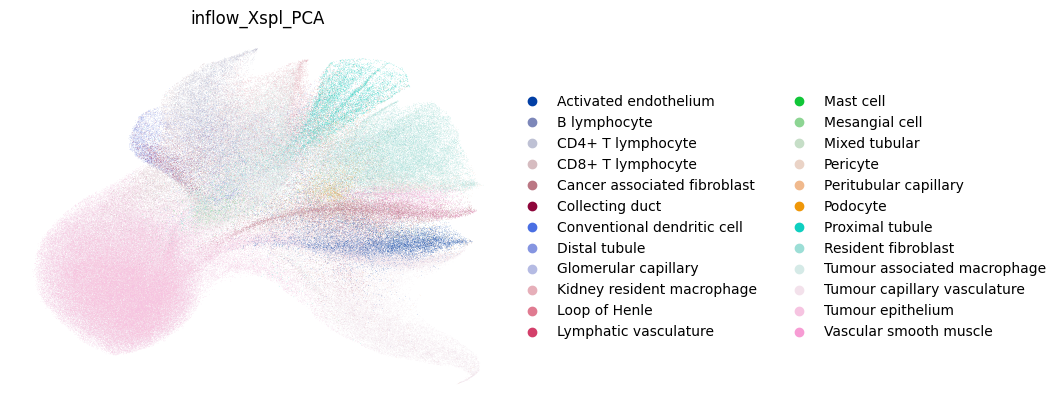

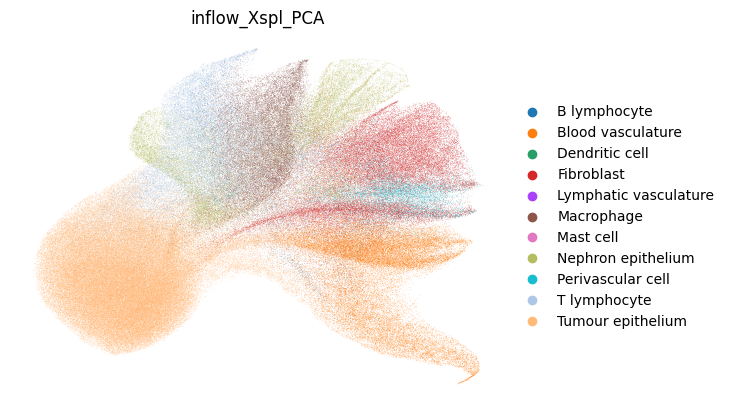

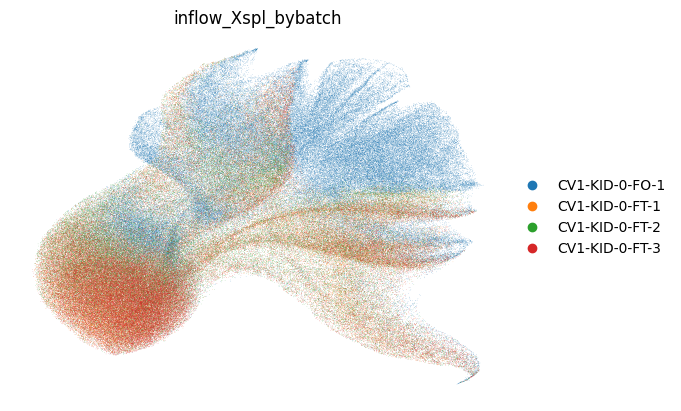

In [343]:
### GENERATES FIGURE 5B AND SUPPLEMENTARY S7A-B

## Perform PCA, nearest neighbors and UMAP based on X spatial for whole dataset

t_tic = time.time()
varto_use = 'inflow_Xspl'
from sklearn.decomposition import PCA
pca = PCA(n_components=10)
adata.obsm[varto_use+"_PCA"] = pca.fit_transform(adata.obsm[varto_use])
sc.pp.neighbors(adata, use_rep=varto_use+"_PCA")
sc.tl.umap(adata)
sc.pl.umap(
    adata,
    color='level_3_cell_type',
    show=False,
    title=varto_use+"_PCA",
    frameon=False
)
sc.pl.umap(
    adata,
    color='level_2_cell_type',
    show=False,
    title=varto_use+"_PCA",
    frameon=False
)
## Compare to plot by batch
sc.pl.umap(
    adata,
    color='batch',
    show=False,
    title=varto_use+"_bybatch",
    frameon=False
)
print("Took {} seconds.".format(time.time() - t_tic))

running Leiden clustering
    finished: found 18 clusters and added
    'total spatial clusters', the cluster labels (adata.obs, categorical) (0:25:30)


/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning:

The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning

/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



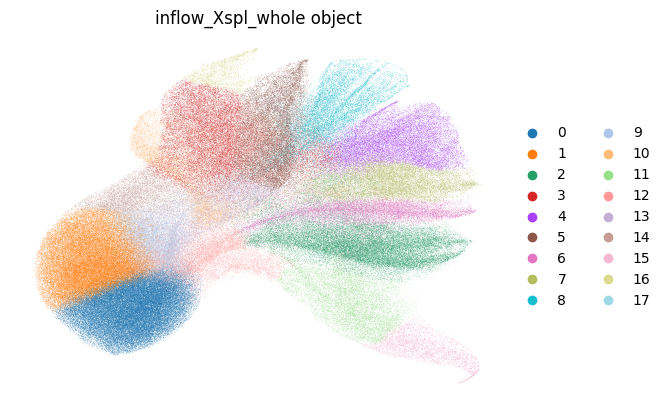

In [345]:
### GENERATE FIGURE 5B

## Identify spatially defined clusters

# Perform Leiden clustering
sc.tl.leiden(adata, resolution=0.7, key_added='total spatial clusters')

# Plot UMAP with the new annotation
sc.pl.umap(adata,
           color=['total spatial clusters'],
           title=varto_use + "_whole object",
           frameon=False)

/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning:

The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning



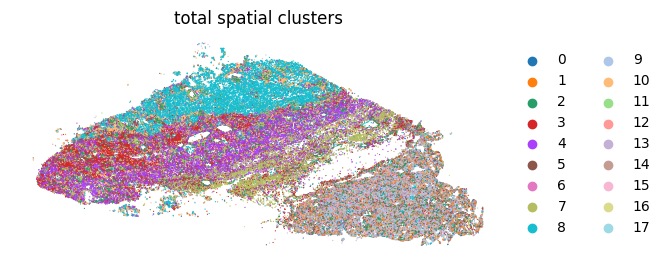

/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning:

The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning



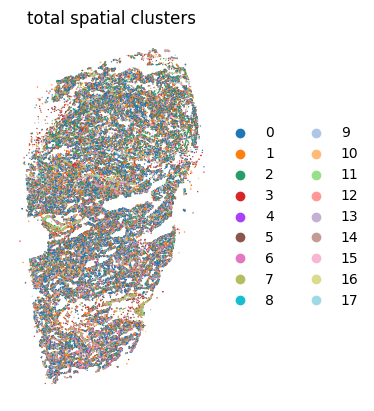

/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning:

The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning



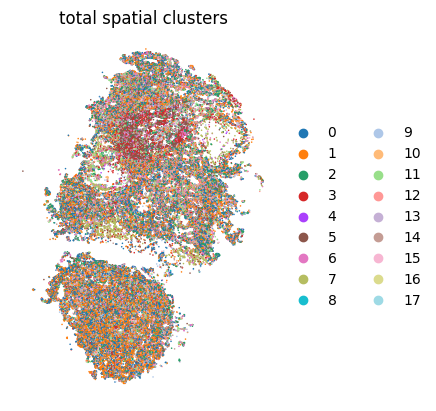

/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning:

The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning



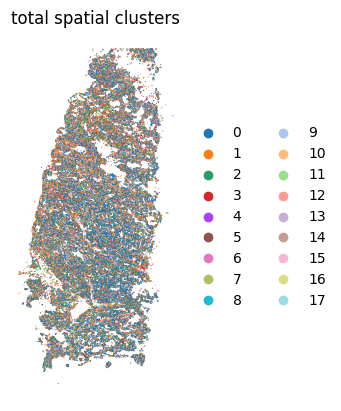

In [346]:
### GENERATE FIGURE 5C, CAN CHANGE 'COLOR' FOR CELL TYPE ANNOTATIONS SPATIAL PLOTS
### CROPS USED FOR FIGURE 5D

## Spatial plotting of spatially-defined cell subclusters

batch_id1 = "CV1-KID-0-FO-1"
batch_id2 = "CV1-KID-0-FT-1"
batch_id3 = "CV1-KID-0-FT-2"
batch_id4 = "CV1-KID-0-FT-3"

adata_batch1 = adata[adata.obs['batch'] == batch_id1]
adata_batch2 = adata[adata.obs['batch'] == batch_id2]
adata_batch3 = adata[adata.obs['batch'] == batch_id3]
adata_batch4 = adata[adata.obs['batch'] == batch_id4]

# Plot spatial data
sc.pl.spatial(adata_batch1, color='total spatial clusters', size=1.5, spot_size=20, frameon=False)
sc.pl.spatial(adata_batch2, color='total spatial clusters', size=1.5, spot_size=20, frameon=False)
sc.pl.spatial(adata_batch3, color='total spatial clusters', size=1.5, spot_size=20, frameon=False)
sc.pl.spatial(adata_batch4, color='total spatial clusters', size=1.5, spot_size=20, frameon=False)


In [294]:
## Subset T cells

adata_Tcell = adata[adata.obs['level_2_cell_type'] == 'T lymphocyte'].copy() # Subset the AnnData object
print(adata_Tcell)

AnnData object with n_obs × n_vars = 32551 × 5001
    obs: 'batch', 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', '_scvi_batch', '_scvi_labels', 'SCVI_CLUSTERS_KEY', 'cell_area_highlight', 'low_quality_cell_highlight', 'level_1_cell_type', 'level_2_cell_type', 'level_3_cell_type', 'donor', 'inflow_CT', 'inflow_BatchID', 'interesting_T_cells', 'spatial_clusters'
    uns: 'inflow_map_Batchname_to_inflowBatchID', 'inflow_map_CT_to_inflowCT', 'rank_genes_groups', 'SCVI_CLUSTERS_KEY_colors', 'spatial_clusters_colors'
    obsm: 'X_scVI', 'X_umap', 'spatial', 'inflow_Xint', 'inflow_Xspl

/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning:

Observation names are not unique. To make them unique, call `.obs_names_make_unique`.



computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:01)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:12)
Took 16.015386819839478 seconds.


/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning:

The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning

/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



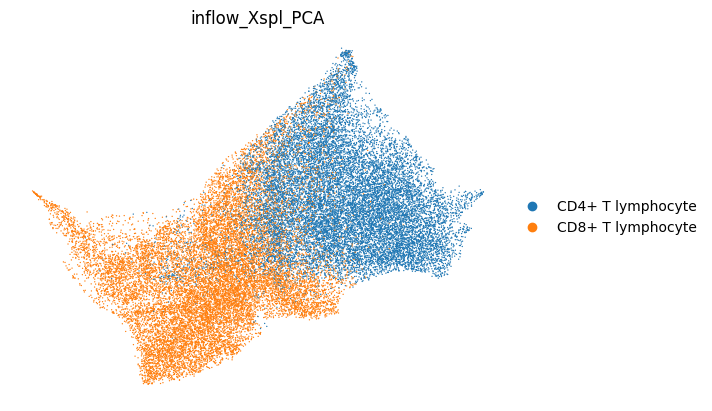

In [295]:
### GENERATE FIGURE 5E

# Perform PCA, nearest neighbors and UMAP based on X spatial for T cells
t_tic = time.time()
varto_use = 'inflow_Xspl'
from sklearn.decomposition import PCA
pca = PCA(n_components=15)
adata_Tcell.obsm[varto_use+"_PCA"] = pca.fit_transform(adata_Tcell.obsm[varto_use])
sc.pp.neighbors(adata_Tcell, use_rep=varto_use+"_PCA")
sc.tl.umap(adata_Tcell)
sc.pl.umap(
    adata_Tcell,
    color='level_3_cell_type',
    show=False,
    title=varto_use+"_PCA",
    frameon=False
)
print("Took {} seconds.".format(time.time() - t_tic))

running Leiden clustering
    finished: found 14 clusters and added
    'spatial clusters', the cluster labels (adata.obs, categorical) (0:00:20)


/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning:

The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning

/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



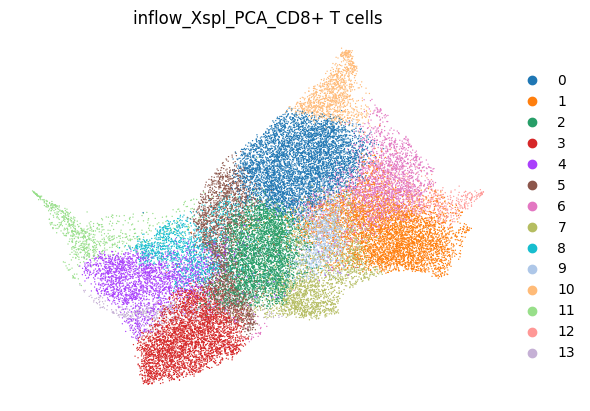

In [307]:
## Identify spatially defined T cell subclusters

# Perform Leiden clustering
sc.tl.leiden(adata_Tcell, resolution=0.7, key_added='spatial clusters')

# Plot UMAP with the new annotation
sc.pl.umap(adata_Tcell,
           color=['spatial clusters'],
           title=varto_use + "_T cells",
           frameon=False)

normalizing counts per cell
    finished (0:00:00)
ranking genes


/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/numpy/core/fromnumeric.py:86: FutureWarning:

The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)



    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:10)


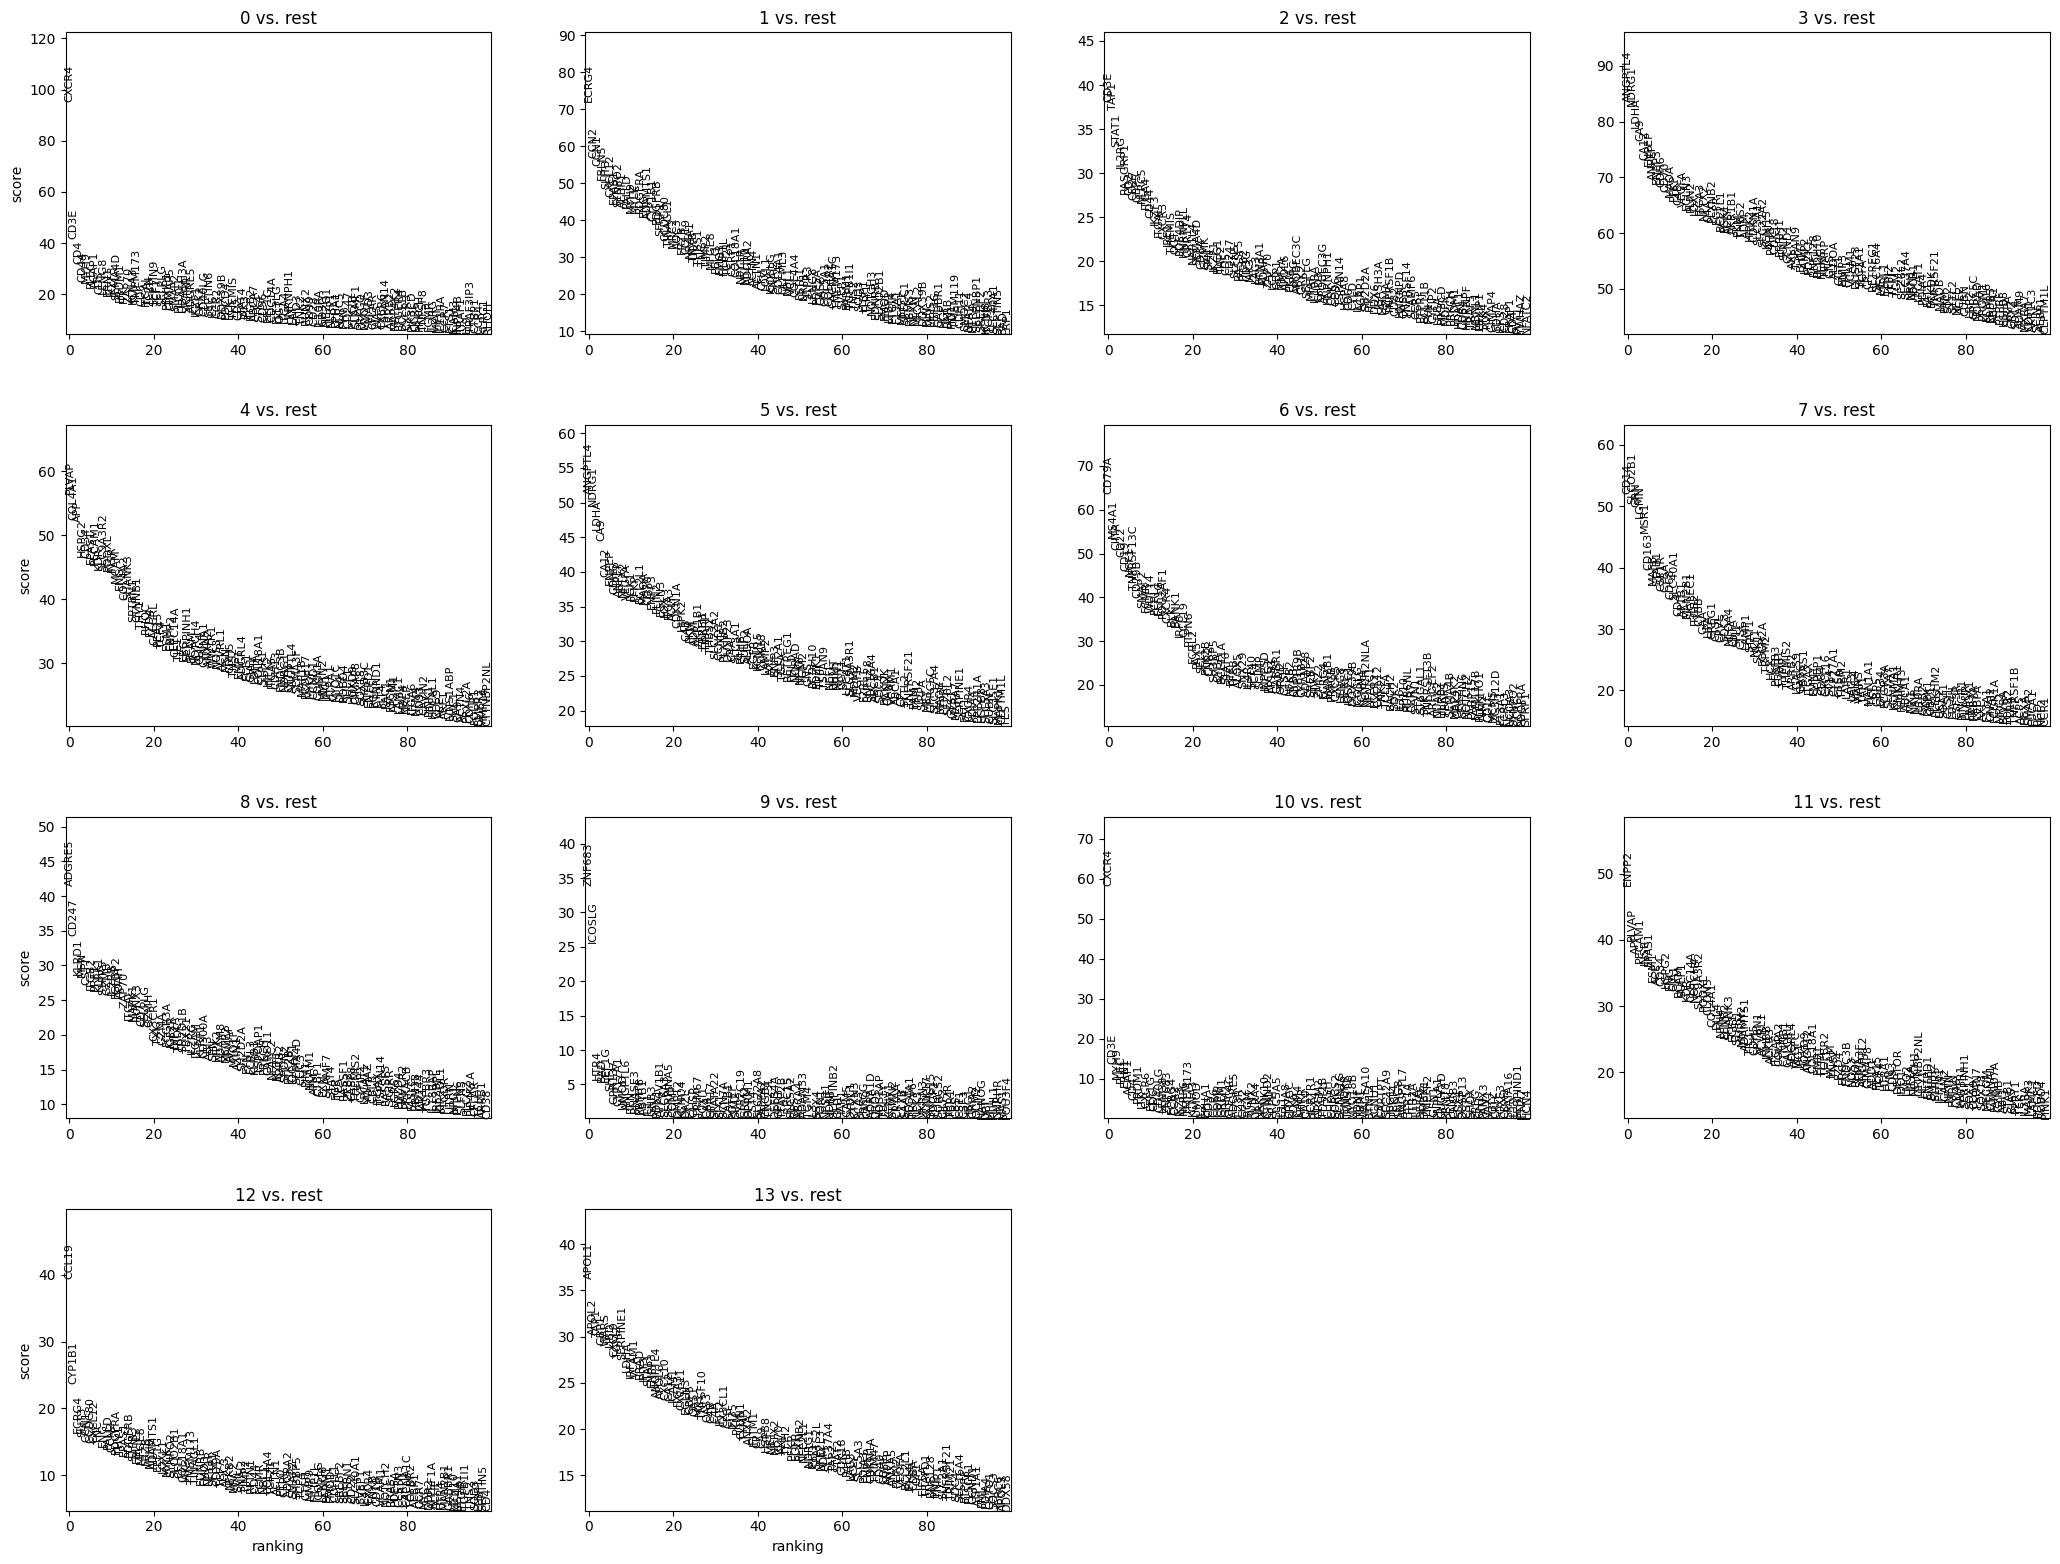

Top genes in 0:
['CXCR4' 'CD3E' 'CD4' 'CD44' 'MYH9' 'PLEC' 'ACAP1' 'CD5' 'LENG8' 'ERN1'
 'IKZF3' 'SEMA4D' 'PRDM1' 'ITK' 'ZAP70' 'KCNA3' 'TMEM173' 'CD6' 'ITGAL'
 'TC2N' 'SEPTIN9' 'TCF7' 'SELPLG' 'PBXIP1' 'GIMAP5' 'SMAP2' 'PLCG1'
 'UBASH3A' 'SIGIRR' 'ADGRE5' 'IKZF1' 'GRK2' 'CD40LG' 'SEPTIN6' 'IL16'
 'CCR2' 'DDX39B' 'PDCD4' 'LCK' 'THEMIS' 'CD2' 'STAT4' 'JAK3' 'ITGB2'
 'ABCA7' 'STK4' 'CD96' 'EEF1G' 'CDC14A' 'FLT3LG' 'OGT' 'ITGA4' 'HNRNPH1'
 'LAT' 'CHD3' 'TNK2' 'RUNX2' 'CD99' 'CD28' 'IL10RA' 'CD3G' 'PIEZO1'
 'NLRP1' 'EPHA1' 'NLRC5' 'FYN' 'CD247' 'PTK2B' 'SLAMF1' 'PRKCQ' 'MYO1F'
 'SMAD3' 'CFLAR' 'WAS' 'CXCR6' 'TSPAN14' 'ARRB2' 'MAP4K2' 'PTGER4'
 'BCL11B' 'CXCR3' 'PIK3CD' 'CCR6' 'PRKCH' 'TNFSF8' 'FCMR' 'IL2RG' 'MIAT'
 'IL11RA' 'CCR7' 'ETS1' 'ICAM3' 'INPP4B' 'TRAF1' 'LY9' 'TRAF3IP3' 'CTBP1'
 'CCR4' 'KLRG1' 'RHOH']
Top genes in 1:
['ECRG4' 'CCN2' 'CCN1' 'FBLN5' 'SLIT3' 'CXCL12' 'EPAS1' 'SYNPO2' 'AEBP1'
 'PALLD' 'MYH9' 'MYLK' 'PDGFRA' 'ENG' 'ADAMTS1' 'CYP1B1' 'PDGFRB' 'SFRP1'
 'CCDC80' 'TINAGL1'

In [325]:
## Runs differential expression for spatially defined T cell subsets

# Normalize total counts per cell (if not already done)
sc.pp.normalize_total(adata_Tcell, target_sum=1e4)
sc.pp.log1p(adata_Tcell)

# Now run the differential expression analysis using these counts
sc.tl.rank_genes_groups(adata_Tcell, groupby='spatial clusters', method='wilcoxon')
sc.pl.rank_genes_groups(adata_Tcell, n_genes=100, sharey=False)

# Optionally, view the top genes per cluster
result = adata_Tcell.uns['rank_genes_groups']
groups = result['names'].dtype.names  # cluster names
for group in groups:
    print(f"Top genes in {group}:")
    print(result['names'][group][:100])

In [326]:
# SAVE OBJECT SO THAT CLUSTER LABELS ARE SAVED!

adata_Tcell.write("/nfs/team361/dj17/inflow_inputsandoutputs/inflow_outputs/version4_lowanneal/adata_Tcell_prelabelling.h5ad")
#adata_Tcell = sc.read_h5ad("/nfs/team361/dj17/inflow_inputsandoutputs/inflow_outputs/version4_lowanneal/adata_Tcell_prelabelling.h5ad")


/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored



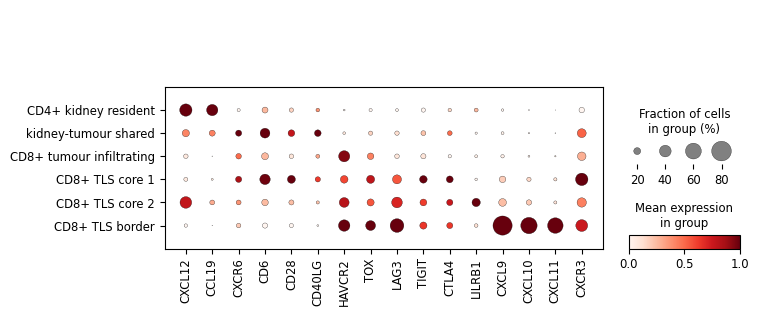

/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning:

The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning

/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



<Axes: title={'center': 'inflow_Xspl_PCA'}, xlabel='UMAP1', ylabel='UMAP2'>

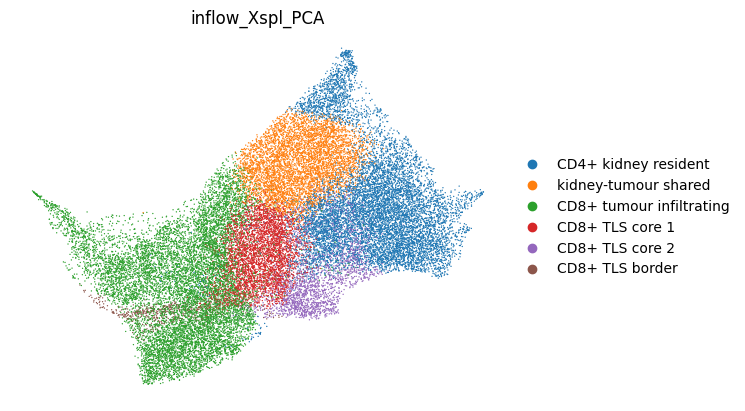

In [359]:
### GENERATE OTHER UMAP IN FIGURE 5E, AND DOTPLOT IN 5G

## Examine genes of interest in spatially defined T cell populations

# Ensure spatial cluster labels are strings (just in case)
adata_Tcell.obs['spatial clusters'] = adata_Tcell.obs['spatial clusters'].astype(str)

# Define the mapping from cluster number to label
cluster_name_map = {
    '0': 'kidney-tumour shared',
    '1': 'CD4+ kidney resident',
    '2': 'CD8+ TLS core 1',
    '3': 'CD8+ tumour infiltrating',
    '4': 'CD8+ tumour infiltrating',
    '5': 'CD8+ tumour infiltrating',
    '6': 'CD4+ kidney resident',
    '7': 'CD8+ TLS core 2',
    '8': 'CD8+ tumour infiltrating',
    '9': 'CD4+ kidney resident',
    '10': 'CD4+ kidney resident',
    '11': 'CD8+ tumour infiltrating',
    '12': 'CD4+ kidney resident',
    '13': 'CD8+ TLS border'
}

# Create the new column using map
adata_Tcell.obs['MintFlow spatial labels'] = adata_Tcell.obs['spatial clusters'].map(cluster_name_map)

# Set the order of categories for plotting
desired_order = [
    'CD4+ kidney resident',
    'kidney-tumour shared',
    'CD8+ tumour infiltrating',
    'CD8+ TLS core 1',
    'CD8+ TLS core 2',
    'CD8+ TLS border'
]

adata_Tcell.obs['MintFlow spatial labels'] = pd.Categorical(
    adata_Tcell.obs['MintFlow spatial labels'],
    categories=desired_order,
    ordered=True
)

selected_genes = [
    # Kidney resident enriched
    'CXCL12', 'CCL19', 'CXCR6',

    # Mixed enriched
    'CD6', 'CD28', 'CD40LG',
    
    # Immune Checkpoints - tumour enriched
    'HAVCR2', 'TOX', 'LAG3', 'TIGIT', 'CTLA4',  'LILRB1',

    # Border TLS enriched - CXCR3 axis
    'CXCL9', 'CXCL10', 'CXCL11', 'CXCR3'
    
]

sc.pl.dotplot(adata_Tcell, var_names=selected_genes, groupby='MintFlow spatial labels',
              standard_scale='var'
             )

sc.pl.umap(
    adata_Tcell,
    color='MintFlow spatial labels',
    show=False,
    title=varto_use+"_PCA",
    frameon=False
)

/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning:

The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning



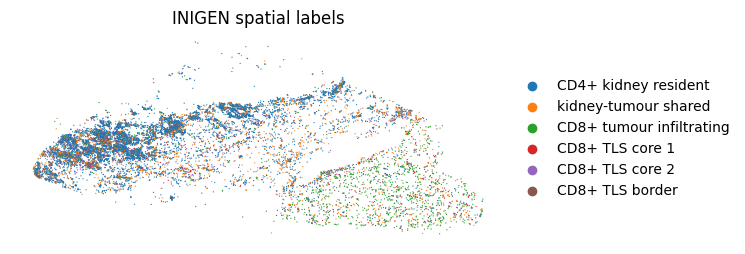

/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning:

The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning



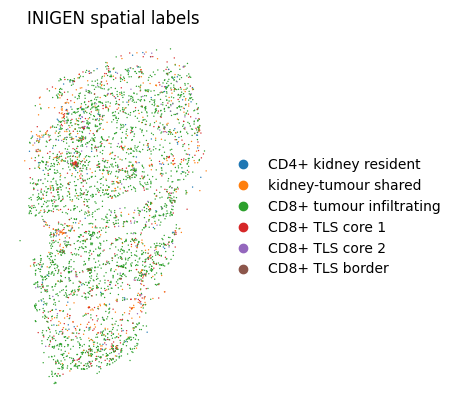

/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning:

The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning



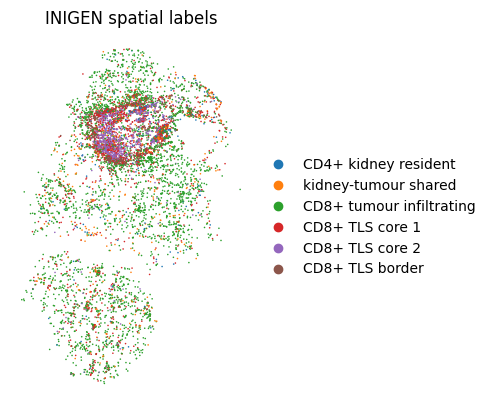

/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning:

The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning



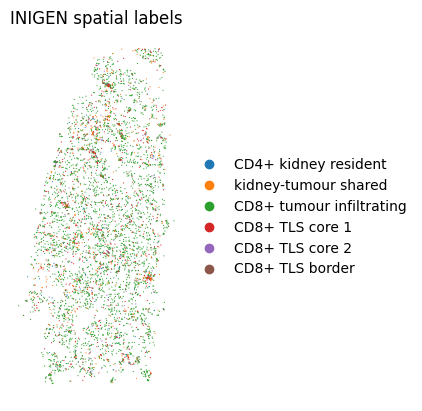

In [351]:
### TUNE TO GENERATE SPATIAL PLOTS IN 5E AND 5F

## Spatial plotting of spatially-defined T cell subclusters with annotations

batch_id1 = "CV1-KID-0-FO-1"
batch_id2 = "CV1-KID-0-FT-1"
batch_id3 = "CV1-KID-0-FT-2"
batch_id4 = "CV1-KID-0-FT-3"

adata_Tcell_batch1 = adata_Tcell[adata_Tcell.obs['batch'] == batch_id1]
adata_Tcell_batch2 = adata_Tcell[adata_Tcell.obs['batch'] == batch_id2]
adata_Tcell_batch3 = adata_Tcell[adata_Tcell.obs['batch'] == batch_id3]
adata_Tcell_batch4 = adata_Tcell[adata_Tcell.obs['batch'] == batch_id4]

# Plot spatial data
sc.pl.spatial(adata_Tcell_batch1, color='MintFlow spatial labels', size=1.5, spot_size=20, frameon=False)
sc.pl.spatial(adata_Tcell_batch2, color='MintFlow spatial labels', size=1.5, spot_size=20, frameon=False)
sc.pl.spatial(adata_Tcell_batch3, color='MintFlow spatial labels', size=1.5, spot_size=20, frameon=False)
sc.pl.spatial(adata_Tcell_batch4, color='MintFlow spatial labels', size=1.5, spot_size=20, frameon=False)

normalizing counts per cell
    finished (0:00:00)
ranking genes


/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/numpy/core/fromnumeric.py:86: FutureWarning:

The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)



    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:13)


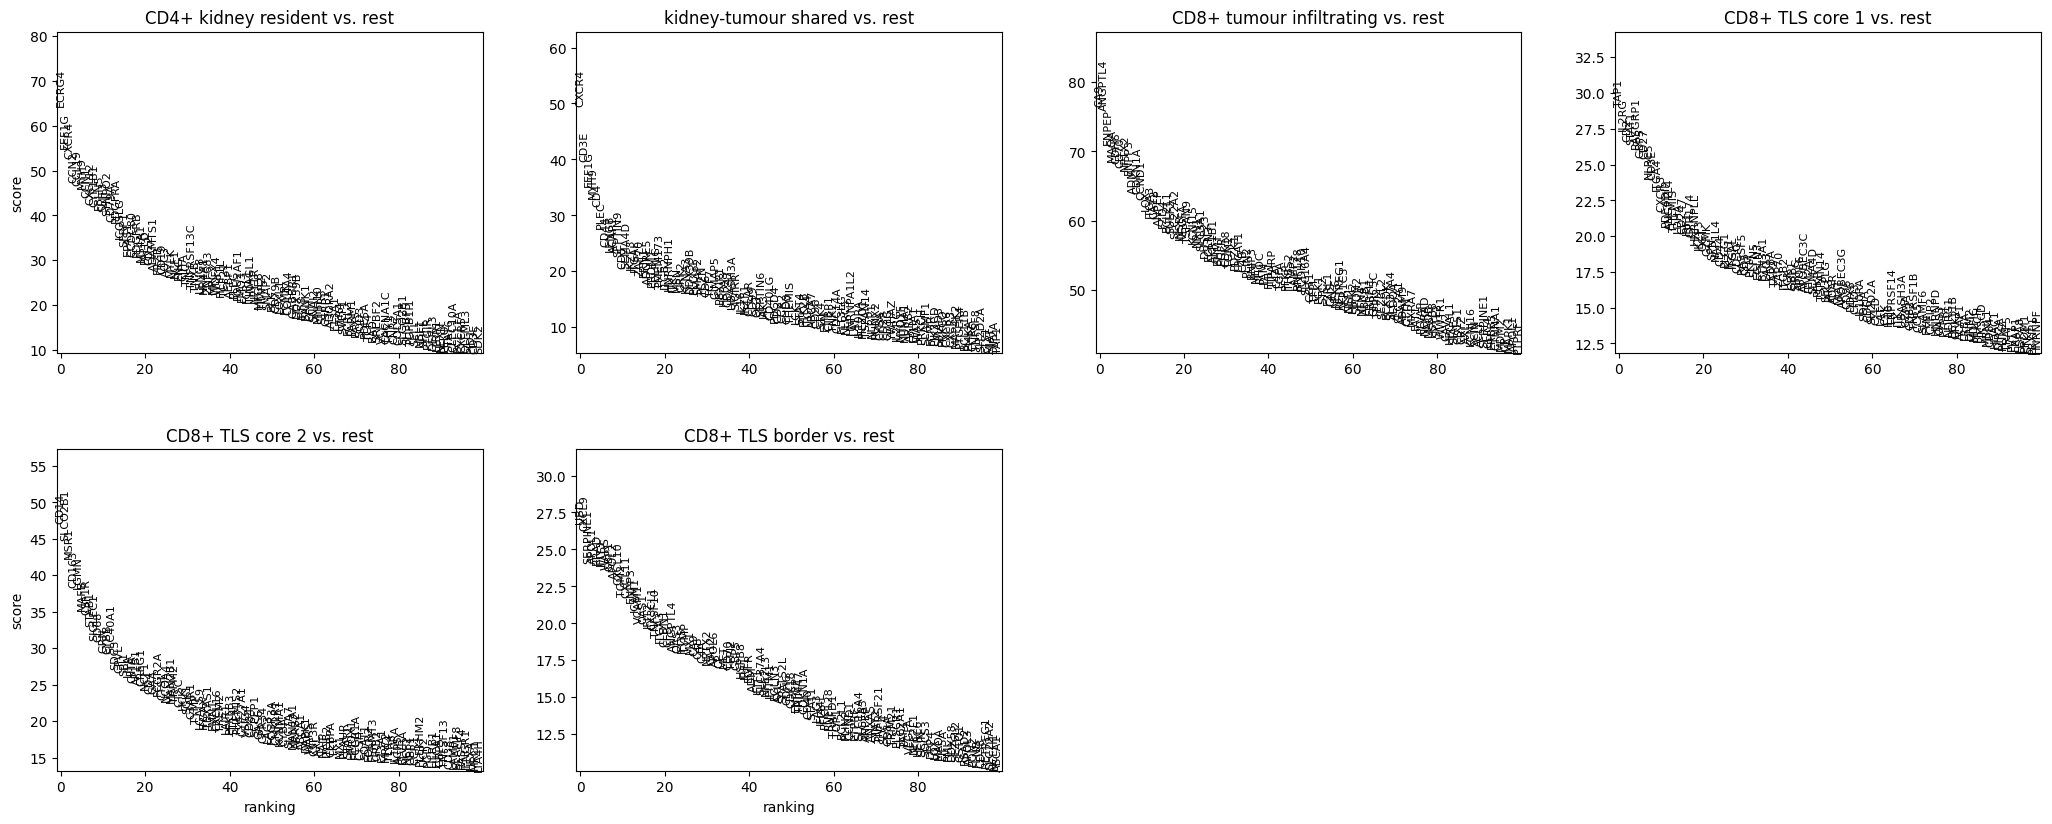

Top genes in CD4+ kidney resident:
['ECRG4' 'EEF1G' 'CXCR4' 'CCN2' 'CCL19' 'MYH9' 'CCN1' 'CXCL12' 'CYP1B1'
 'FBLN5' 'SLIT3' 'SYNPO2' 'CD79A' 'PDGFRA' 'ICOSLG' 'SFRP1' 'EPAS1'
 'CCDC80' 'PDGFRB' 'MS4A1' 'PALLD' 'CD22' 'ADAMTS1' 'FRZB' 'CD19' 'AOC3'
 'MYLK' 'NCF1' 'ENG' 'CIITA' 'TNC' 'TNFRSF13C' 'TNXB' 'LENG8' 'NR4A1'
 'ZNF683' 'MRC2' 'WDFY4' 'FILIP1L' 'TCF21' 'AEBP1' 'PLEC' 'POU2AF1' 'FMO3'
 'FCRL1' 'TINAGL1' 'NPY1R' 'MFGE8' 'TIMP2' 'SMAP2' 'BLK' 'CD79B' 'LOXL1'
 'FCMR' 'COL4A4' 'GABBR1' 'DDX39B' 'IRF8' 'BANK1' 'CFH' 'SNAI2' 'MYH10'
 'S1PR3' 'CSRP1' 'ADGRA2' 'F13A1' 'HTR4' 'SVEP1' 'FCRL2' 'PARM1' 'PAX5'
 'SOD3' 'PDE5A' 'TCF4' 'BAD' 'SREBF2' 'VCL' 'CACNA1C' 'THY1' 'CNR2'
 'COL5A1' 'SLCO2B1' 'SH3BP5' 'TGFB1I1' 'SELL' 'NBL1' 'SHFL' 'PTGIR'
 'DERL3' 'LTBP1' 'NEXN' 'PELO' 'STAT6' 'CLEC10A' 'BCL11A' 'CXCR5' 'OLFML3'
 'PID1' 'CD3E' 'SDK2']
Top genes in kidney-tumour shared:
['CXCR4' 'CD3E' 'EEF1G' 'MYH9' 'CD4' 'PLEC' 'CD44' 'LENG8' 'ACAP1'
 'SEPTIN9' 'CD5' 'SEMA4D' 'IKZF3' 'ITGAL' 'ZAP70' 'ERN

In [368]:
## Runs differential expression for spatially defined T cell subsets - now labelled

# Normalize total counts per cell (if not already done)
sc.pp.normalize_total(adata_Tcell, target_sum=1e4)
sc.pp.log1p(adata_Tcell)

# Now run the differential expression analysis using these counts
sc.tl.rank_genes_groups(adata_Tcell, groupby='MintFlow spatial labels', method='wilcoxon')
sc.pl.rank_genes_groups(adata_Tcell, n_genes=100, sharey=False)

# Optionally, view the top genes per cluster
result = adata_Tcell.uns['rank_genes_groups']
groups = result['names'].dtype.names  # cluster names
for group in groups:
    print(f"Top genes in {group}:")
    print(result['names'][group][:100])

In [339]:
# SAVE OBJECT SO THAT CLUSTER LABELS ARE SAVED!

#adata_Tcell.write("/nfs/team361/dj17/inflow_inputsandoutputs/inflow_outputs/version4_lowanneal/adata_Tcell_postlabelling.h5ad")
#adata_Tcell = sc.read_h5ad("/nfs/team361/dj17/inflow_inputsandoutputs/inflow_outputs/version4_lowanneal/adata_Tcell_postlabelling.h5ad")

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:02)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:14)
Took 54.18537211418152 seconds.


/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


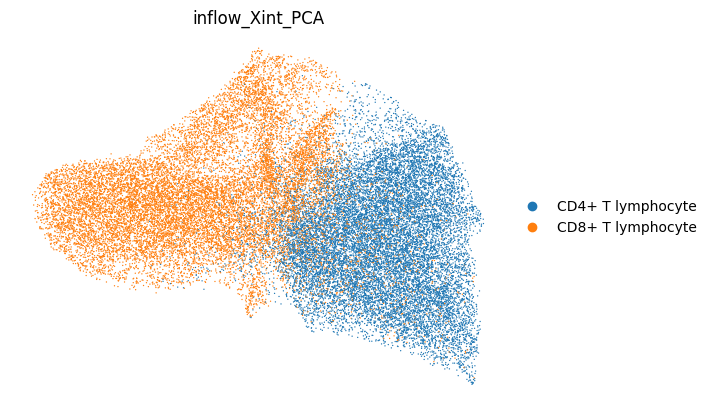

In [183]:
### GENERATES FIGURE SUPPLEMENTARY S8A

# Perform PCA, nearest neighbors and UMAP based on X intrinsic (spatial clusters still saved!), with clustering

t_tic = time.time()
varto_use = 'inflow_Xint'
adata_Tcell.obsm[varto_use+"_PCA"] = pca.fit_transform(adata_Tcell.obsm[varto_use])
sc.pp.neighbors(adata_Tcell, use_rep=varto_use+"_PCA")
sc.tl.umap(adata_Tcell)
sc.pl.umap(
    adata_Tcell,
    color='level_3_cell_type',
    show=False,
    title=varto_use+"_PCA",
    frameon=False
)
print("Took {} seconds.".format(time.time() - t_tic))

running Leiden clustering
    finished: found 12 clusters and added
    'intrinsic clusters', the cluster labels (adata.obs, categorical) (0:00:19)


/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning:

The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning

/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



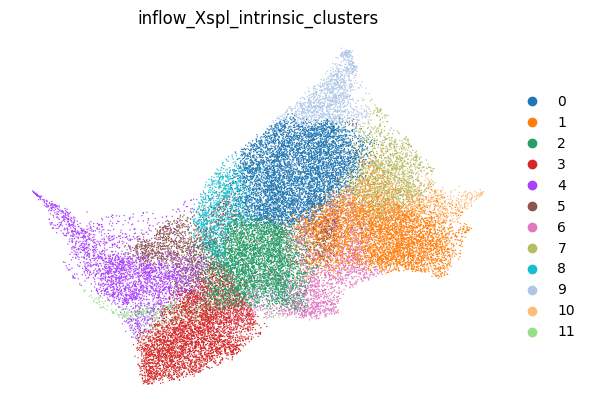

/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning:

The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning

/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



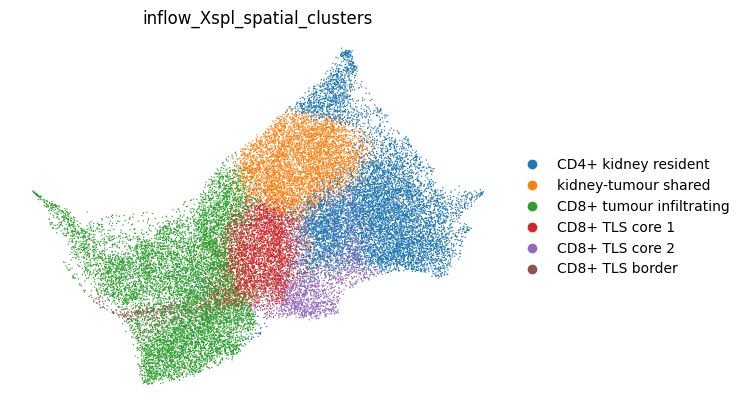

In [365]:
# Perform Leiden clustering
#sc.tl.leiden(adata_Tcell, resolution=0.6, key_added='intrinsic clusters')

# Plot UMAP with the new annotation
sc.pl.umap(adata_Tcell,
           color=['intrinsic clusters'],
           title=varto_use + "_intrinsic_clusters",
           frameon=False)

# Plot UMAP with the new annotation
sc.pl.umap(adata_Tcell,
           color=['MintFlow spatial labels'],
           title=varto_use + "_spatial_clusters",
           frameon=False)

/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


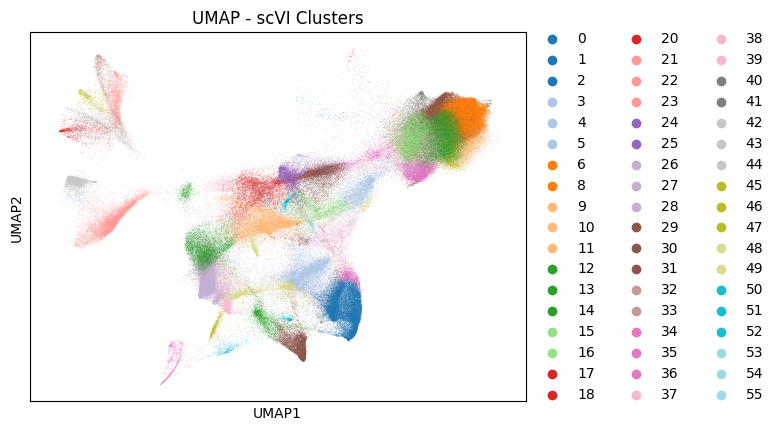

/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


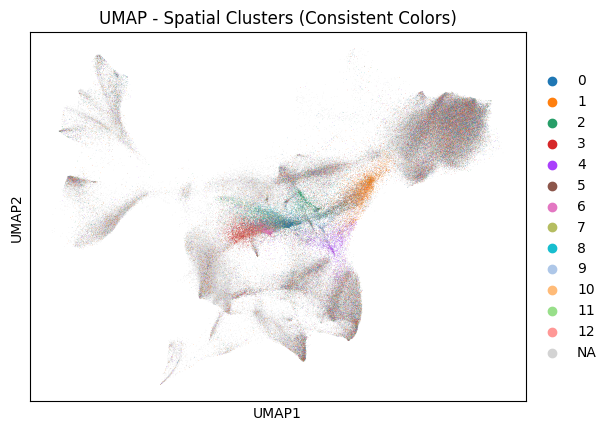

In [192]:
### GENERATES FIGURE SUPPLEMENTARY S8B

# Deduplicate by taking the first label for each index (cell)
spatial_labels_deduped = adata_Tcell.obs['INIGEN spatial labels'].groupby(adata_Tcell.obs_names).first()

# Now map onto the main adata safely
adata.obs['MintFlow spatial labels'] = adata.obs_names.map(spatial_labels_deduped)
# Copy the color mapping from adata_Tcell
adata.uns['MintFlow spatial labels_colors'] = adata_Tcell.uns['MintFlow spatial labels_colors']


sc.pl.umap(adata, color='SCVI_CLUSTERS_KEY', title='UMAP - scVI Clusters', palette='tab20')

sc.pl.umap(
    adata,
    color='MintFlow spatial labels',
    title='UMAP - Spatial Clusters (Consistent Colors)',
    na_color='lightgray',
    palette=adata.uns['spatial_clusters_colors']  # optional if the key is correctly named
)


In [197]:
# Drop cells with missing values in either cluster label
valid = adata.obs[['spatial_clusters', 'SCVI_CLUSTERS_KEY']].dropna()

from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Compute Adjusted Rand Index (ARI)
ari = adjusted_rand_score(valid['SCVI_CLUSTERS_KEY'], valid['spatial_clusters'])
print(f"Adjusted Rand Index: {ari:.3f}")

# Compute Normalized Mutual Information (NMI)
nmi = normalized_mutual_info_score(valid['SCVI_CLUSTERS_KEY'], valid['spatial_clusters'])
print(f"Normalized Mutual Information: {nmi:.3f}")

Adjusted Rand Index: 0.041
Normalized Mutual Information: 0.072


In [348]:
# Define base output directory
output_dir = "/nfs/users/nfs_d/dj17/inflow_DJ"

# List of INIGEN spatial cluster labels to extract
target_labels = ["CD8+ TLS core 1", "CD8+ TLS core 2", "CD8+ TLS border"]

# Loop through each label and save cell IDs to a separate file
for label in target_labels:
    # Get cell IDs for the current label
    cell_ids = adata_Tcell.obs[adata_Tcell.obs['INIGEN spatial labels'] == label].index.tolist()
    
    # Generate a clean filename from the label (replace spaces and '+' for safety)
    filename = label.replace(" ", "_").replace("+", "pos") + "_cell_ids.txt"
    output_path = f"{output_dir}/{filename}"
    
    # Write cell IDs to file
    with open(output_path, "w") as f:
        for cid in cell_ids:
            f.write(f"{cid}\n")